In [166]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import cv2

import pymupdf  # or: import fitz as pymupdf

from huggingface_hub import hf_hub_download
from doclayout_yolo import YOLOv10

from yolo.pdf_utils import render_page_to_image, image_bbox_to_pdf_bbox
from yolo.iou_matching import (
    text_elements_from_spans,
    layout_regions_from_detections,
    match_elements_to_layout,
)

from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn

In [167]:
# Configuration
PDF_PATH = "../examples/Test.pdf"   # or your target PDF
PAGE_IDX = 0

# Hugging Face DocLayout-YOLO model
REPO_ID = "juliozhao/DocLayout-YOLO-DocStructBench"
FILENAME = "doclayout_yolo_docstructbench_imgsz1024.pt"

# Paths for existing PyMuPDF metadata
JSON_PATH = f"../data_layout/page_{PAGE_IDX}/page_{PAGE_IDX}_layout.json"
IMAGE_PATH = f"../data_layout/page_{PAGE_IDX}/page_{PAGE_IDX}_image.png"  # optional backup

# Download model once (cached by huggingface_hub)
MODEL_PATH = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)

# Load DocLayout-YOLO model (YOLOv10-based)
doclayout_model = YOLOv10(MODEL_PATH)

# Open PDF and page
doc = pymupdf.open(PDF_PATH)
page = doc[PAGE_IDX]

# Render page to image for YOLO detection
render_result = render_page_to_image(page, dpi=300)
page_image_pil = render_result.image
scale_x, scale_y = render_result.scale_x, render_result.scale_y

# Also keep a NumPy image for visualization (RGB)
page_image = np.array(page_image_pil)


0: 1024x800 4 titles, 6 plain texts, 3 abandons, 2155.3ms
Speed: 10.4ms preprocess, 2155.3ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 800)
Detected 13 layout regions with DocLayout-YOLO.


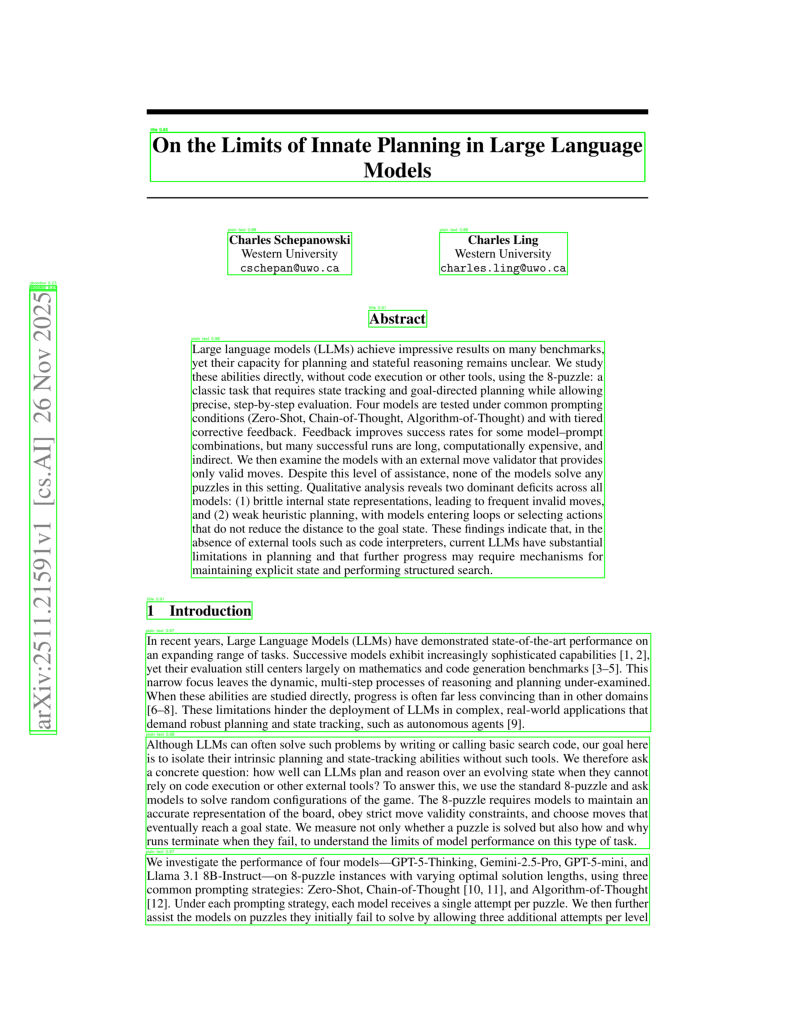

In [168]:
# Load PyMuPDF JSON metadata
with open(JSON_PATH, "r", encoding="utf-8") as f:
    pdf_elements = json.load(f)

# Run DocLayout-YOLO (YOLOv10) on the page image
results = doclayout_model.predict(
    page_image,        # RGB numpy array
    imgsz=1024,
    conf=0.2,
    device="cpu",     # keep CPU-only
)

r = results[0]
boxes = r.boxes.xyxy.cpu().numpy()
scores = r.boxes.conf.cpu().numpy()
class_ids = r.boxes.cls.cpu().numpy().astype(int)
names = r.names or doclayout_model.names

# Convert to our standard detection dict format (image coordinates)
det_dicts = []
for (x0, y0, x1, y1), score, cid in zip(boxes, scores, class_ids):
    det_dicts.append({
        "bbox": (float(x0), float(y0), float(x1), float(y1)),
        "score": float(score),
        "class_id": int(cid),
        "class_name": str(names.get(int(cid), f"class_{cid}")),
    })

print(f"Detected {len(det_dicts)} layout regions with DocLayout-YOLO.")

# ---- Visualization of YOLO detections on the page image (image coordinates) ----
vis_img = page_image.copy()  # RGB NumPy array
for det in det_dicts:
    x0, y0, x1, y1 = map(int, det["bbox"])
    label = f"{det['class_name']} {det['score']:.2f}"
    cv2.rectangle(vis_img, (x0, y0), (x1, y1), (0, 255, 0), 2)
    cv2.putText(
        vis_img,
        label,
        (x0, max(0, y0 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.4,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(10, 14))
plt.imshow(vis_img)
plt.axis("off")
plt.show()

# ---- Convert YOLO bboxes from image space to PDF coordinate space ----
for det in det_dicts:
    x0, y0, x1, y1 = det["bbox"]
    pdf_bbox = image_bbox_to_pdf_bbox((x0, y0, x1, y1), scale_x, scale_y)
    det["bbox"] = pdf_bbox  # overwrite with PDF-space bbox

In [ ]:
# Build text elements (from PyMuPDF spans) and YOLO layout regions
all_spans = []
for elem in pdf_elements:
    if elem.get("type") == "text":
        all_spans.extend(elem.get("spans", []))

text_elements = text_elements_from_spans(all_spans)
layout_regions = layout_regions_from_detections(det_dicts)

# IoU-based matching of spans to YOLO layout regions
layout_blocks = match_elements_to_layout(
    text_elements=text_elements,
    layout_regions=layout_regions,
    iou_threshold=0.4,  # tune as needed
)

In [170]:
from itertools import groupby

# Sort layout_blocks: top-to-bottom (by y0), then left-to-right (by x0)
# This ensures blocks are processed in reading order
layout_blocks = sorted(
    layout_blocks,
    key=lambda b: (b.bbox[1])  # (y0, x0)
)

# Sort laybot_blocks into row
rows = []
current_row = []
row_threshold = 10  # points
for b in layout_blocks:
    top_y = b.bbox[1]
    
    if not current_row:
        current_row = [b]
        current_top = top_y
    else:
        # So sánh top_y để xác định cùng hàng
        if abs(top_y - current_top) <= row_threshold:
            current_row.append(b)
        else:
            rows.append(sorted(current_row, key=lambda x: x.bbox[0]))  # sort left→right
            current_row = [b]
            current_top = top_y

if current_row:
    rows.append(sorted(current_row, key=lambda x: x.bbox[0]))


print(f"Matched into {len(layout_blocks)} logical layout blocks (sorted top-to-bottom, left-to-right).")
for b in layout_blocks:
    print(b.block_type, ":", b.text[:80], "...")

Matched into 9 logical layout blocks (sorted top-to-bottom, left-to-right).
title : On the Limits of Innate Planning in Large Language ...
plain text : Charles Schepanowski Western University cschepan@uwo.ca ...
plain text : Charles Ling Western University charles.ling@uwo.ca ...
abandon : arXiv:2511.21591v1  [cs.AI]  26 Nov 2025 ...
title : Abstract ...
title : Introduction ...
plain text : In recent years, Large Language Models (LLMs) have demonstrated state-of-the-art ...
plain text : Although LLMs can often solve such problems by writing or calling basic search c ...
plain text : We investigate the performance of four models—GPT-5-Thinking, Gemini-2.5-Pro, GP ...


In [171]:
# Optional: quick summary of block types detected by YOLO
from collections import Counter

block_type_counts = Counter(b.block_type for b in layout_blocks)
print("Block type counts:", block_type_counts)

Block type counts: Counter({'plain text': 5, 'title': 3, 'abandon': 1})


In [172]:
# Utility to clean PDF font names for DOCX
def clean_font_name(pdf_font_name):
    # ex: "TimesNewRomanPS-BoldMT" -> "TimesNewRoman"
    # remove suffixes after "-"
    clean_name = pdf_font_name.split("-")[0]
    if "TimesNewRoman" in clean_name:
        return "Times New Roman"
    if "Arial" in clean_name:
        return "Arial"
    return clean_name

In [173]:

# Utilities to set up table with border = none
def is_same_line(b1, b2, tol=10):
    # compare mid-y of blocks in PDF points
    mid1 = (b1.bbox[1] + b1.bbox[3]) / 2.0
    mid2 = (b2.bbox[1] + b2.bbox[3]) / 2.0
    return abs(mid1 - mid2) <= tol

def horizontally_separated(b1, b2, min_gap=20):
    # ensure they are non-overlapping and have a horizontal gap larger than threshold
    # b.x0 = bbox[0], b.x1 = bbox[2]
    left = min(b1.bbox[0], b2.bbox[0])
    right = max(b1.bbox[2], b2.bbox[2])
    width_sum = (b1.bbox[2] - b1.bbox[0]) + (b2.bbox[2] - b2.bbox[0])
    gap = (right - left) - width_sum
    # gap > min_gap means they are separated
    return gap >= min_gap

def remove_table_borders(table):
    for row in table.rows:
        for cell in row.cells:
            tc = cell._tc
            tcPr = tc.get_or_add_tcPr()
            # remove existing tcBorders if any
            existing = tcPr.xpath('w:tcBorders')
            if existing:
                tcPr.remove(existing[0])
            # create empty tcBorders (val=none)
            tcBorders = OxmlElement('w:tcBorders')
            for pos in ('top', 'left', 'bottom', 'right', 'insideH', 'insideV'):
                elem = OxmlElement(f"w:{pos}")
                elem.set(qn('w:val'), 'nil')  # 'nil' or 'none' both acceptable
                tcBorders.append(elem)
            tcPr.append(tcBorders)
            
def set_table_col_widths(table, col_widths_pts):
    """
    Set column widths (in points). Requires table.autofit = False.
    col_widths_pts: list of widths in points
    """
    table.autofit = False
    for col_idx, width in enumerate(col_widths_pts):
        for cell in table.columns[col_idx].cells:
            cell.width = Inches(width / 72.0)  # convert points to inches

def group_spans_into_lines(elems, y_tol=3.0):
    """
    elems: list of TextElement (with .bbox and .text)
    Group spans into visual lines by their mid-y coordinate.
    Return list of lines, each line is list of elems sorted by x0.
    """
    if not elems:
        return []
    # compute mid-y
    spans = []
    for e in elems:
        x0, y0, x1, y1 = e.bbox
        midy = (y0 + y1) / 2.0
        spans.append((midy, x0, e))
    # cluster by midy
    spans.sort(key=lambda t: (t[0], t[1]))
    lines = []
    current_line = [spans[0][2]]
    current_midy = spans[0][0]
    for midy, x0, e in spans[1:]:
        if abs(midy - current_midy) <= y_tol:
            current_line.append(e)
            # keep current_midy as average for robustness
            current_midy = (current_midy * (len(current_line)-1) + midy) / len(current_line)
        else:
            # sort current line by x0
            current_line = sorted(current_line, key=lambda ee: ee.bbox[0])
            lines.append(current_line)
            current_line = [e]
            current_midy = midy
    # append last
    current_line = sorted(current_line, key=lambda ee: ee.bbox[0])
    lines.append(current_line)
    return lines

In [ ]:
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

# Create DOCX from YOLO-based layout blocks

doc = Document()
MAX_IMAGE_WIDTH = Inches(6.0)   # max width for images
STYLE_MAP = {
    "title":           {"style": "Title"},
    "section_header":  {"style": "Heading 1"},
    "list":            {"style": "List Bullet"},
    "caption":         {"style": "Caption"},
    "footnote":        {"style": "Intense Quote"},
    "page_header":     {"style": "Header"},
    "page_footer":     {"style": "Footer"},
    "text":            {"style": "Normal"},
    "figure":          None,
    "table":           None,
}

section = doc.sections[0]
# doc_left_margin in inches
try:
    doc_left_margin_in = section.left_margin.inches
except Exception:
    # fallback if .inches isn't available: convert from points
    doc_left_margin_in = section.left_margin.pt / 72.0
    
# Usable page width in points (page width minus margins)
page_width_pts = section.page_width.pt
left_margin_pts = section.left_margin.pt
right_margin_pts = section.right_margin.pt
usable_width_pts = page_width_pts - left_margin_pts - right_margin_pts

prev_row_y1 = 0

# Main loop for writing rows to doc
for row in rows:
    # Sort left-to-right
    row.sort(key=lambda b: b.bbox[0])
    
    # Use table only if len(row) >= 2 and pairwise satisfy conditions
    use_table = False
    if len(row) >= 2:
        # Check that at least two blocks on the row are roughly same-line and horizontally separated
        # If only 1 block does not satisfy, no table
        all_pairs_ok = True
        for i in range(len(row) - 1):
            if not (is_same_line(row[i], row[i+1]) and horizontally_separated(row[i], row[i+1], min_gap=20)):
                all_pairs_ok = False
                break
        use_table = all_pairs_ok
    
    # CASE: USE TABLE
    if use_table and len(row) >= 2:
        # Compute indent (convert from PDF pixels → points)
        min_x_pt = min(b.bbox[0] for b in row)  # already in points
        doc_left_margin_pt = section.left_margin.pt
        indent_pt = max(min_x_pt - doc_left_margin_pt, 0.0)
        
        # Create table
        num_cols = len(row)
        table = doc.add_table(rows=1, cols=num_cols)
        table.autofit = False
        remove_table_borders(table)
        
        # Apply table indent
        tbl = table._tbl
        tblPr = tbl.tblPr
        
        if tblPr is None:
            tblPr = OxmlElement("w:tblPr")
            tbl.append(tblPr)
        
        for e in tblPr.findall(qn("w:tblInd")):
            tblPr.remove(e) 

        tblInd = OxmlElement("w:tblInd")
        tblInd.set(qn("w:w"), str(int(indent_pt * 20)))  # TWIPS
        tblInd.set(qn("w:type"), "dxa")
        tblPr.append(tblInd)
        
        # 4) Compute each column width exactly from PDF width
        col_widths_pt = []
        for b in row:
            w_px = b.bbox[2] - b.bbox[0]
            w_pt = w_px / PX_PER_PT
            col_widths_pt.append(w_pt)

        for col_idx, w in enumerate(col_widths_pt):
            for cell in table.columns[col_idx].cells:
                cell.width = Pt(w)
                
        # Fill table cells — keep exact line breaks
        for col_idx, block in enumerate(row):
            cell = table.rows[0].cells[col_idx]
            # remove default empty paragraph properly (safe)
            cell.text = ""

            lines = block.text.split("\n")
            for line in lines:
                p = cell.add_paragraph()
                p.paragraph_format.space_after = Pt(0)

                run = p.add_run(line)
                if block.elements and block.elements[0].font_size:
                    run.font.size = Pt(block.elements[0].font_size)

            # Center (authors usually centered)
            for p in cell.paragraphs:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER

        prev_row_y1 = max(b.bbox[3] for b in row)
        continue
    
    # CASE: NOT USE TABLE
    for block in row:
        block_type = block.block_type

        # Ignore if block_type = "abandon"
        if block_type == "abandon":
            continue
        
        # Image / figure handling
        if block_type == "figure":
            # Convert PDF bbox to image pixel coordinates using scale_x/scale_y
            x0_pdf, y0_pdf, x1_pdf, y1_pdf = block.bbox
            x0 = int(max(0, x0_pdf * scale_x))
            y0 = int(max(0, y0_pdf * scale_y))
            x1 = int(min(page_image.shape[1], x1_pdf * scale_x))
            y1 = int(min(page_image.shape[0], y1_pdf * scale_y))

            crop_img = page_image[y0:y1, x0:x1]
            if crop_img.size == 0:
                continue

            temp_image_path = "temp_crop.png"
            cv2.imwrite(temp_image_path, cv2.cvtColor(crop_img, cv2.COLOR_RGB2BGR))
            p = doc.add_paragraph()
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            run = p.add_run()
            run.add_picture(temp_image_path, width=MAX_IMAGE_WIDTH)
            continue
        
        # Text handling
        style_info = STYLE_MAP.get(block_type, {"style": "Normal"})
        if style_info is None:
            continue

        style_name = style_info["style"]
        if style_name.startswith("Heading"):
            p = doc.add_heading(level=int(style_name.split()[-1]))
        else:
            p = doc.add_paragraph(style=style_name)
            
        # Positioning based on PDF coordinates
        x0_pdf, y0_pdf, x1_pdf, y1_pdf = block.bbox
        # Left indent relative to document left margin
        x0_in = x0_pdf / 72
        indent_from_margin_in = max(0.0, x0_in - doc_left_margin_in)
        p.paragraph_format.left_indent = Inches(indent_from_margin_in)
        
        # Just need to set space_before for the 1st block in a row
        if block == row[0] and prev_row_y1 > 0:
            vertical_gap = max(0, (y0_pdf - prev_row_y1))  # PDF units
            p.paragraph_format.space_before = Pt(vertical_gap)
        else:
            p.paragraph_format.space_before = Pt(0)

        p.paragraph_format.space_after = Pt(2)
        
        for elem in block.elements:
            text_content = elem.text
            if not text_content.endswith(" "):
                text_content += " "
            run = p.add_run(text_content)
            if elem.font_name:
                run.font.name = clean_font_name(elem.font_name)
            if elem.font_size is not None:
                run.font.size = Pt(elem.font_size)
            if elem.font_flags is not None:
                run.bold = (elem.font_flags & 16) != 0
                run.italic = (elem.font_flags & 8) != 0
                
    prev_row_y1 = max(b.bbox[3] for b in row)      

# Save the reconstructed DOCX
output_path = "../docx_file/test_yolo.docx"
print(f"Saving DOCX to: {output_path}")
doc.save(output_path)

Saving DOCX to: ../docx_file/test_yolo.docx


In [175]:
for block in layout_blocks:
    print(f"Layout text: {block.text}")
    print(f"Layout bbox: {block.bbox}")
    for elem in block.elements:
        print(f"Text element text: {elem.text}")
        print(f"Text element bbox: {elem.bbox}")
        print(f"Text element flags: {elem.font_flags}")
    print("\n")

Layout text: On the Limits of Innate Planning in Large Language
Layout bbox: (111.07477294921874, 97.51322021484374, 501.52740234375, 136.2968994140625)
Text element text: On the Limits of Innate Planning in Large Language
Text element bbox: (112.38800048828125, 99.8338394165039, 499.6141662597656, 117.04924011230469)
Text element flags: 20


Layout text: Charles Schepanowski Western University cschepan@uwo.ca
Layout bbox: (171.8756103515625, 176.4718212890625, 269.952626953125, 209.8035791015625)
Text element text: Charles Schepanowski
Text element bbox: (172.91000366210938, 177.7974853515625, 268.8498229980469, 187.7600860595703)
Text element flags: 20
Text element text: Western University
Text element bbox: (182.60400390625, 188.7974395751953, 259.1566467285156, 198.76004028320312)
Text element flags: 4
Text element text: cschepan@uwo.ca
Text element bbox: (181.6610107421875, 199.9554443359375, 260.116455078125, 209.9180450439453)
Text element flags: 12


Layout text: Charles Ling W